# Análisis completo de un retailer online

### Pregunta que guía el análisis

¿Quiénes son los mejores clientes del retailer y qué productos conviene recomendarles o promocionar juntos para vender más?

Todo el notebook responde a esa pregunta. La limpieza prepara los datos, el análisis estadístico describe el negocio y valida la depuración, la segmentación identifica los tipos de cliente según su comportamiento, y las reglas de asociación indican qué productos empaquetar o recomendar. El cierre es un tablero que resume los hallazgos.

### Sobre el dataset

Transacciones de una tienda online del Reino Unido entre diciembre de 2010 y diciembre de 2011. Cada fila es un producto dentro de una factura, con su cantidad, precio, fecha, cliente y país. El análisis se concentra en el Reino Unido, que representa el 91% de las operaciones.

| Columna | Descripción |
|---|---|
| InvoiceNo | Número de factura. Si empieza con C es una cancelación |
| StockCode | Código del producto |
| Description | Nombre del producto |
| Quantity | Unidades compradas |
| InvoiceDate | Fecha y hora de la operación |
| UnitPrice | Precio unitario en libras |
| CustomerID | Identificador del cliente |
| Country | País del cliente |


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

df = pd.read_excel("../data/external/Online_Retail.xlsx")
print(f"Dimensiones originales: {df.shape}")
df.head()


Dimensiones originales: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. Exploración inicial

Antes de limpiar conviene entender la estructura del dataset y dimensionar los problemas de calidad. Se revisan tipos, nulos, duplicados y valores imposibles.


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [3]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

print("Nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"Cancelaciones (factura con C): {df['InvoiceNo'].str.startswith('C').sum()}")
print(f"Cantidades negativas o cero: {(df['Quantity'] <= 0).sum()}")
print(f"Precios negativos o cero: {(df['UnitPrice'] <= 0).sum()}")


Nulos por columna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64



Filas duplicadas: 5268


Cancelaciones (factura con C): 9288
Cantidades negativas o cero: 10624
Precios negativos o cero: 2517


Los problemas detectados son varios y de distinta naturaleza.

Hay 135.080 filas sin `CustomerID`, una cuarta parte del total. Sin cliente identificado esas operaciones no sirven para segmentar, pero sí para analizar productos.

Aparecen 1.454 descripciones nulas, 5.268 duplicados exactos y unas 9.000 cancelaciones, que son devoluciones registradas como cantidades negativas.

También existen valores imposibles, cantidades y precios negativos o en cero, que son errores o ajustes administrativos.


## 2. Limpieza

Las decisiones se toman pensando en el objetivo. El interés está en compras reales de clientes del Reino Unido, así que se descarta todo lo que no represente una venta efectiva.


### Decisiones de limpieza

**Filtrar al Reino Unido.** Concentra el 91% de las ventas y evita mezclar mercados con volúmenes muy distintos.

**Eliminar duplicados.** Filas idénticas que inflan artificialmente los conteos.

**Eliminar cancelaciones.** Las facturas que empiezan con C son devoluciones, no ventas, y distorsionan el análisis de compra.

**Eliminar cantidades y precios no positivos.** Una venta real tiene cantidad y precio mayores a cero.

**Eliminar descripciones nulas.** Sin nombre de producto no se puede usar en el análisis de canasta.

**Conservar las filas sin `CustomerID`, pero separarlas.** Se mantienen para el análisis de productos y asociación, que no necesitan cliente, y se excluyen solo en la segmentación, que sí lo requiere. Así se aprovecha la mayor cantidad de datos en cada fase.

**Crear la columna `TotalPrice`.** El gasto de cada línea es la cantidad por el precio unitario, base de casi todas las métricas posteriores.


In [4]:
inicial = len(df)

df = df[df["Country"] == "United Kingdom"].copy()
df = df.drop_duplicates()
df = df[~df["InvoiceNo"].str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.dropna(subset=["Description"])
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(f"Filas iniciales: {inicial:,}")
print(f"Filas tras limpieza: {len(df):,}  ({len(df)/inicial*100:.0f}% del total)")

# Dataset para segmentación, solo con cliente identificado
df_cli = df.dropna(subset=["CustomerID"]).copy()
df_cli["CustomerID"] = df_cli["CustomerID"].astype(int)
print(f"Filas con cliente (segmentación): {len(df_cli):,}")
print(f"Clientes únicos: {df_cli['CustomerID'].nunique():,}")
print(f"Facturas únicas: {df['InvoiceNo'].nunique():,}")
print(f"Productos únicos: {df['Description'].nunique():,}")


Filas iniciales: 541,909
Filas tras limpieza: 479,985  (89% del total)
Filas con cliente (segmentación): 349,203
Clientes únicos: 3,920
Facturas únicas: 18,019
Productos únicos: 4,007


### Verificación de redundancia entre variables

Igual que en otros datasets, conviene revisar si alguna variable numérica repite información de otra antes de seguir. Se mira la matriz de correlación entre las variables de cantidad, precio y gasto.


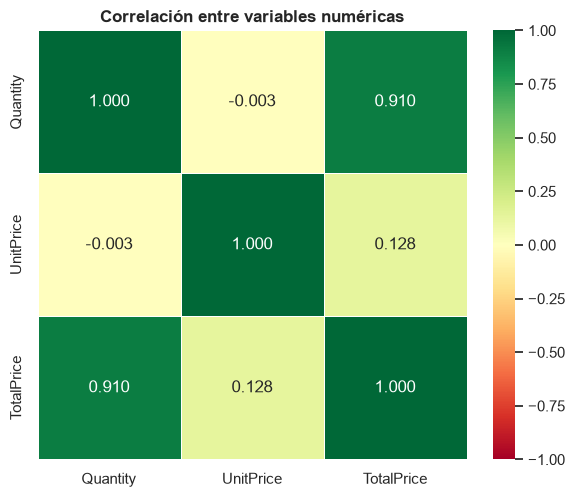

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[["Quantity", "UnitPrice", "TotalPrice"]].corr(),
            annot=True, fmt=".3f", cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlación entre variables numéricas", fontweight="bold")
plt.tight_layout()
plt.show()


Hay un caso de dependencia esperable. `TotalPrice` correlaciona 0.91 con `Quantity`, porque se construye multiplicando cantidad por precio y la mayoría de los productos son baratos, así que el gasto sigue de cerca a la cantidad. Es una variable derivada, igual que `S4` lo era en el dataset de diabetes.

La diferencia es la decisión. Allá la variable derivada se eliminó por redundante. Aquí `TotalPrice` se conserva a propósito, porque es justamente la métrica de negocio que interesa, el dinero gastado, y es la base de casi todo el análisis posterior. La correlación alta no es un problema sino una consecuencia natural de cómo se define.

Por otro lado, `Quantity` y `UnitPrice` son independientes entre sí, con correlación cercana a cero, así que ninguna repite a la otra. No hay redundancia genuina que eliminar.


In [6]:
df.to_csv("../data/processed/retail_limpio.csv", index=False)
print("Dataset limpio guardado en data/processed/retail_limpio.csv")


Dataset limpio guardado en data/processed/retail_limpio.csv


## 3. Análisis estadístico

El análisis describe el negocio y, de paso, valida que la limpieza dejó datos razonables. Se miran las distribuciones de las variables monetarias, la evolución temporal de las ventas, los productos más vendidos y la concentración de ingresos en pocos clientes.


### Distribución de las variables monetarias

Las variables de cantidad y gasto suelen estar muy sesgadas en retail, muchas compras chicas y pocas enormes. Se comprueba con la asimetría y se usa una escala logarítmica para poder visualizarlas.


Quantity     asimetría = 454.6
UnitPrice    asimetría = 234.1
TotalPrice   asimetría = 489.0


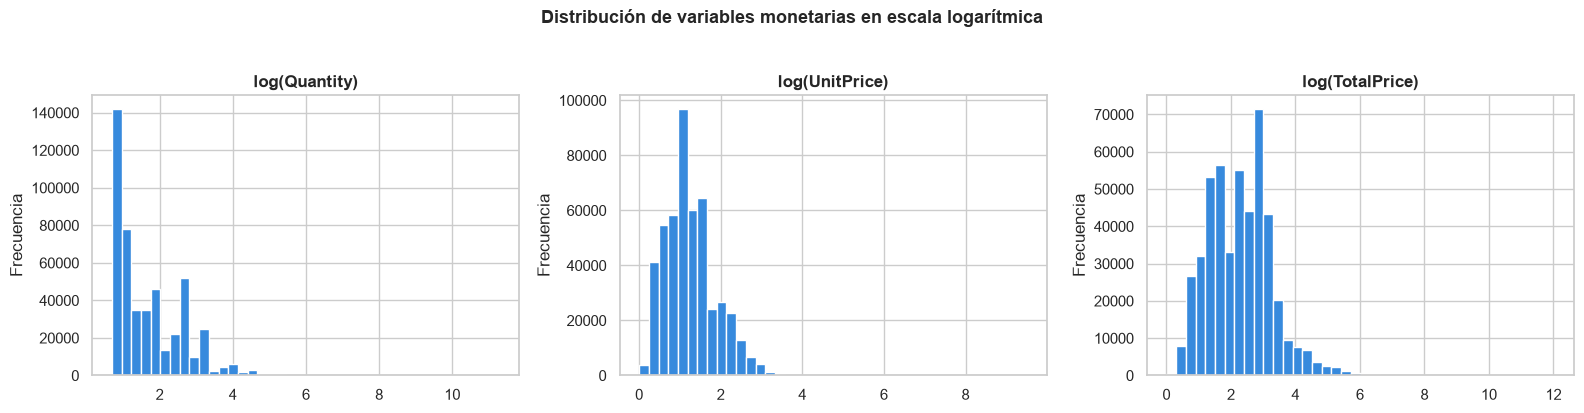

In [7]:
for c in ["Quantity", "UnitPrice", "TotalPrice"]:
    print(f"{c:12} asimetría = {df[c].skew():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["Quantity", "UnitPrice", "TotalPrice"]):
    ax.hist(np.log1p(df[c]), bins=40, color="#378ADD", edgecolor="white")
    ax.set_title(f"log({c})", fontweight="bold")
    ax.set_ylabel("Frecuencia")
fig.suptitle("Distribución de variables monetarias en escala logarítmica", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


La asimetría es altísima, por encima de 200 en las tres variables, lo que confirma que la mayoría de las compras son pequeñas y existen pocas operaciones de gran volumen. En escala logarítmica las distribuciones se vuelven legibles y muestran formas más cercanas a una campana. Esto anticipa que cualquier técnica sensible a la escala, como el clustering, va a necesitar una transformación previa.


### ¿El gasto de los clientes sigue una distribución conocida?

Las variables crudas están demasiado sesgadas para ser normales, pero en retail el gasto acumulado por cliente suele seguir una distribución log-normal, es decir, su logaritmo sí se parece a una campana. Comprobarlo importa por dos razones. Primero, permite describir el comportamiento de gasto con las herramientas de la distribución normal vistas en clase. Segundo, justifica la transformación logarítmica que se aplica más adelante en la segmentación.


Asimetría del gasto crudo: 20.2
Asimetría del log(gasto):  0.36

Shapiro sobre log(gasto): W=0.9902  p=0.0000

Regla 68-95-99.7 sobre log(gasto):
   ±1σ:  empírico  68.8%   vs teórico  68.0%
   ±2σ:  empírico  96.1%   vs teórico  95.0%
   ±3σ:  empírico  99.1%   vs teórico  99.7%


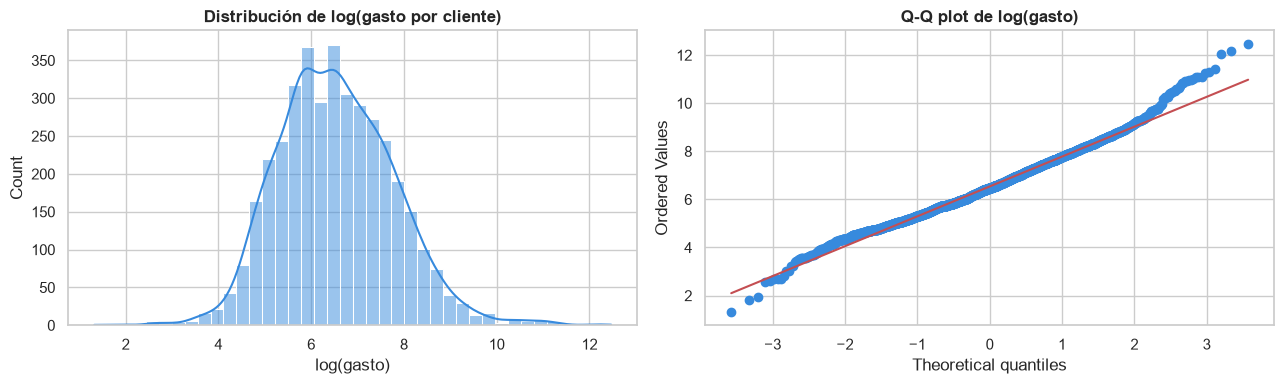

In [8]:
gasto = df_cli.groupby("CustomerID")["TotalPrice"].sum()
log_gasto = np.log(gasto)

print(f"Asimetría del gasto crudo: {gasto.skew():.1f}")
print(f"Asimetría del log(gasto):  {log_gasto.skew():.2f}")

# Prueba de normalidad sobre una muestra y regla empírica
muestra = log_gasto.sample(min(5000, len(log_gasto)), random_state=42)
W, p_sw = stats.shapiro(muestra)
print(f"\nShapiro sobre log(gasto): W={W:.4f}  p={p_sw:.4f}")

m, s = log_gasto.mean(), log_gasto.std()
print("\nRegla 68-95-99.7 sobre log(gasto):")
for k, teorico in [(1, 68.0), (2, 95.0), (3, 99.7)]:
    pct = ((log_gasto >= m - k*s) & (log_gasto <= m + k*s)).mean() * 100
    print(f"   ±{k}σ:  empírico {pct:5.1f}%   vs teórico {teorico:5.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(log_gasto, kde=True, color="#378ADD", bins=40, ax=axes[0])
axes[0].set_title("Distribución de log(gasto por cliente)", fontweight="bold")
axes[0].set_xlabel("log(gasto)")
stats.probplot(log_gasto, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot de log(gasto)", fontweight="bold")
axes[1].get_lines()[0].set_markerfacecolor("#378ADD")
axes[1].get_lines()[0].set_markeredgecolor("#378ADD")
plt.tight_layout()
plt.show()


El logaritmo del gasto pasa de una asimetría enorme a casi cero, y la regla empírica se cumple con mucha precisión, 68.8%, 96.1% y 99.1% frente a los valores teóricos. Aunque la prueba de Shapiro rechaza la normalidad estricta, algo esperable con miles de observaciones donde la prueba es muy sensible, el ajuste es claramente bueno. La conclusión práctica es que el gasto de los clientes sigue una distribución log-normal, un patrón típico en consumo, y por eso trabajar en escala logarítmica es lo correcto para los pasos siguientes.


### Estimación del ticket promedio

Una métrica clave del negocio es cuánto se gasta en promedio por factura. Se estima con un intervalo de confianza, que da el valor probable junto con su margen de error en lugar de un número suelto.


In [9]:
ticket = df.groupby("InvoiceNo")["TotalPrice"].sum()
ic = stats.t.interval(0.95, len(ticket) - 1, loc=ticket.mean(), scale=stats.sem(ticket))

print(f"Ticket promedio: £{ticket.mean():.2f}")
print(f"Intervalo de confianza 95%: [£{ic[0]:.2f}, £{ic[1]:.2f}]")
print(f"Mediana del ticket: £{ticket.median():.2f}")


Ticket promedio: £499.57
Intervalo de confianza 95%: [£473.56, £525.58]
Mediana del ticket: £299.95


Con un 95% de confianza, el gasto promedio por factura está entre 474 y 526 libras. La mediana es bastante menor que la media, lo que vuelve a reflejar la asimetría, unas pocas facturas muy grandes empujan el promedio hacia arriba mientras que la compra típica es más modesta.


### Evolución temporal de las ventas

Se agregan las ventas por mes para detectar estacionalidad, algo clave en un negocio de regalos y artículos para el hogar.


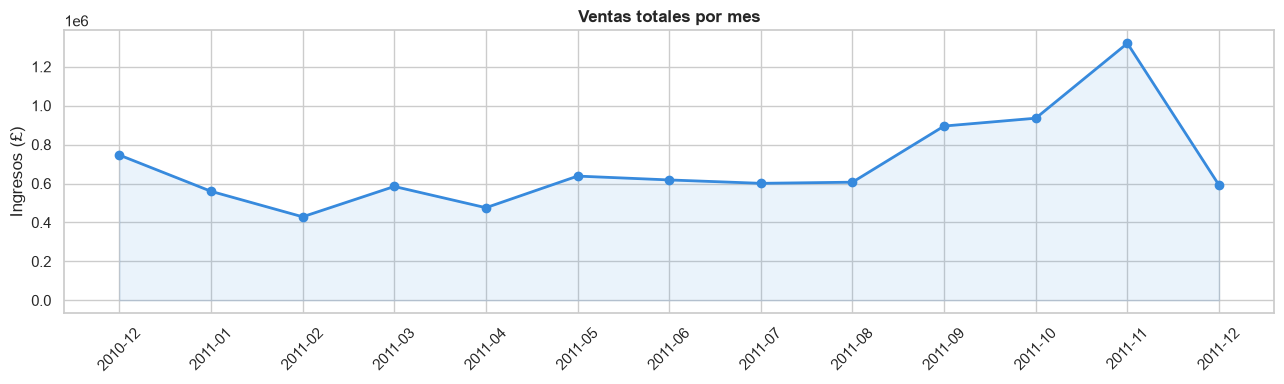

Mes pico: 2011-11 con £1,319,934
Mes más bajo: 2011-02 con £428,987


In [10]:
df["Mes"] = df["InvoiceDate"].dt.to_period("M").astype(str)
ventas_mes = df.groupby("Mes")["TotalPrice"].sum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ventas_mes.index, ventas_mes.values, marker="o", color="#378ADD", linewidth=2)
ax.fill_between(range(len(ventas_mes)), ventas_mes.values, alpha=0.1, color="#378ADD")
ax.set_title("Ventas totales por mes", fontweight="bold")
ax.set_ylabel("Ingresos (£)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"Mes pico: {ventas_mes.idxmax()} con £{ventas_mes.max():,.0f}")
print(f"Mes más bajo: {ventas_mes.idxmin()} con £{ventas_mes.min():,.0f}")


Las ventas crecen con fuerza hacia el final del año y alcanzan su pico en noviembre de 2011, coherente con la temporada previa a la Navidad. El mínimo cae en febrero. La diferencia entre el mes más alto y el más bajo es de más del triple, una estacionalidad marcada que conviene tener presente para planificar promociones y stock.


### Productos más vendidos

Se identifican los productos que más ingresos generan, una primera mirada a qué impulsa el negocio.


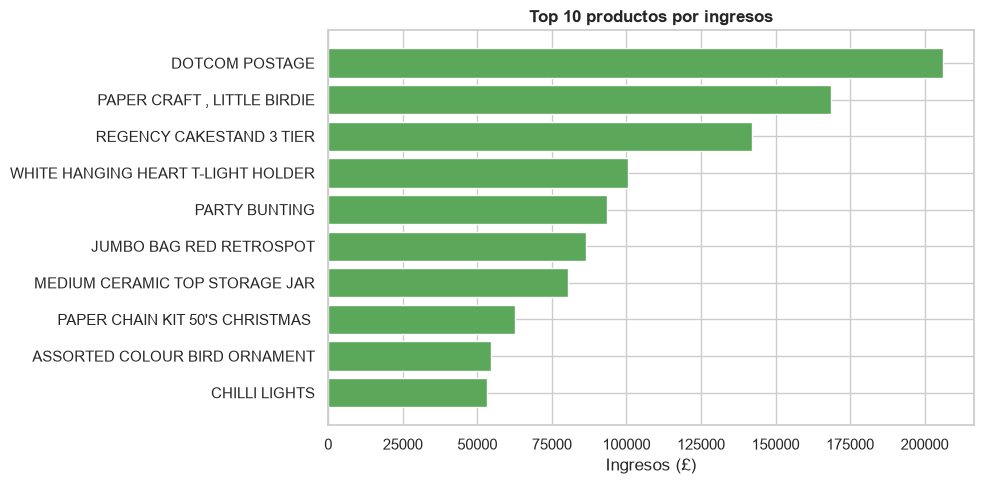

Description
DOTCOM POSTAGE                        206249.0
PAPER CRAFT , LITTLE BIRDIE           168470.0
REGENCY CAKESTAND 3 TIER              141996.0
WHITE HANGING HEART T-LIGHT HOLDER    100445.0
PARTY BUNTING                          93599.0
JUMBO BAG RED RETROSPOT                86291.0
MEDIUM CERAMIC TOP STORAGE JAR         80576.0
PAPER CHAIN KIT 50'S CHRISTMAS         62684.0
ASSORTED COLOUR BIRD ORNAMENT          54589.0
CHILLI LIGHTS                          53315.0
Name: TotalPrice, dtype: float64

In [11]:
top_prod = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_prod.index[::-1], top_prod.values[::-1], color="#5BA85B")
ax.set_title("Top 10 productos por ingresos", fontweight="bold")
ax.set_xlabel("Ingresos (£)")
plt.tight_layout()
plt.show()
top_prod.round(0)


El catálogo está dominado por artículos de decoración y regalo de bajo precio unitario pero alta rotación. Ningún producto concentra una porción dominante, el negocio se sostiene sobre un surtido amplio más que sobre unos pocos éxitos.


### Concentración de ingresos, análisis de Pareto

Una pregunta central para el negocio es cuánto dependen los ingresos de unos pocos clientes. El principio de Pareto sugiere que una minoría suele generar la mayoría de las ventas. Se verifica con los datos.


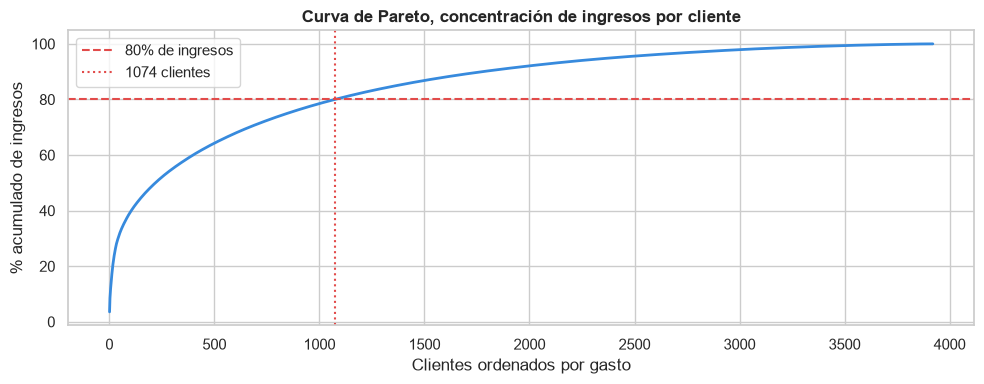

1074 de 3920 clientes (27%) generan el 80% de los ingresos


In [12]:
gasto_cliente = df_cli.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)
acumulado = gasto_cliente.cumsum() / gasto_cliente.sum()
n_80 = (acumulado <= 0.8).sum() + 1
pct_clientes = n_80 / len(gasto_cliente) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(acumulado) + 1), acumulado.values * 100, color="#378ADD", linewidth=2)
ax.axhline(80, color="#E24B4A", linestyle="--", label="80% de ingresos")
ax.axvline(n_80, color="#E24B4A", linestyle=":", label=f"{n_80} clientes")
ax.set_title("Curva de Pareto, concentración de ingresos por cliente", fontweight="bold")
ax.set_xlabel("Clientes ordenados por gasto")
ax.set_ylabel("% acumulado de ingresos")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{n_80} de {len(gasto_cliente)} clientes ({pct_clientes:.0f}%) generan el 80% de los ingresos")


El resultado confirma el principio. Alrededor del 27% de los clientes genera el 80% de los ingresos. Esto justifica directamente el objetivo del análisis, si una minoría sostiene el negocio, identificar quiénes son y retenerlos es la prioridad. La segmentación que sigue apunta justo a eso.


## 4. Segmentación de clientes con RFM y K-Means

Para agrupar a los clientes según su comportamiento se usa el modelo RFM, un estándar en marketing que resume a cada cliente en tres números.

La Recencia mide cuántos días pasaron desde su última compra, menos es mejor. La Frecuencia cuenta cuántas compras distintas hizo, más es mejor. El Monetario suma cuánto gastó en total, más es mejor.

Sobre esas tres variables se aplica K-Means para descubrir grupos naturales de clientes.


In [13]:
fecha_ref = df_cli["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_cli.groupby("CustomerID").agg(
    Recencia=("InvoiceDate", lambda x: (fecha_ref - x.max()).days),
    Frecuencia=("InvoiceNo", "nunique"),
    Monetario=("TotalPrice", "sum"),
).reset_index()

print(rfm[["Recencia", "Frecuencia", "Monetario"]].describe().round(1))
rfm.head()


       Recencia  Frecuencia  Monetario
count    3920.0      3920.0     3920.0
mean       92.2         4.2     1858.4
std        99.5         7.2     7478.6
min         1.0         1.0        3.8
25%        18.0         1.0      298.2
50%        51.0         2.0      645.0
75%       143.0         5.0     1571.3
max       374.0       209.0   259657.3

,CustomerID,Recencia,Frecuencia,Monetario
0,12346,326,1,77183.60
1,12747,2,11,4196.01
2,12748,1,209,33053.19
3,12749,4,5,4090.88
4,12820,3,4,942.34


### Elegir el número de grupos

Las variables RFM están muy sesgadas, así que se transforman con logaritmo y se estandarizan antes de agrupar. Para elegir cuántos grupos formar se combina el coeficiente de silueta, que mide qué tan bien separados están, con el criterio de que los grupos sean accionables para marketing.


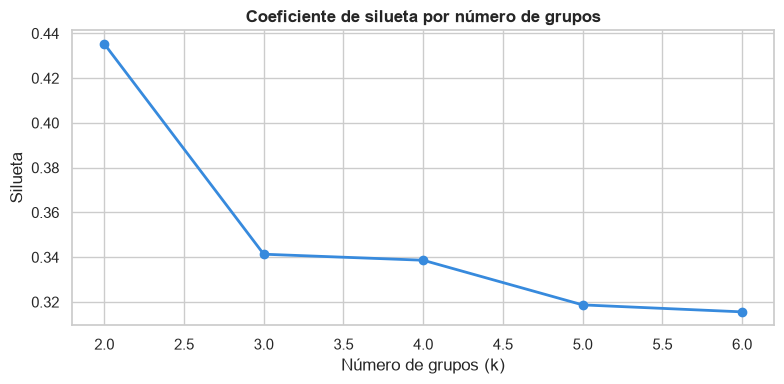

  k=2: silueta=0.435
  k=3: silueta=0.341
  k=4: silueta=0.339
  k=5: silueta=0.319
  k=6: silueta=0.316


In [14]:
X = np.log1p(rfm[["Recencia", "Frecuencia", "Monetario"]])
X_esc = StandardScaler().fit_transform(X)

sil = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_esc)
    sil[k] = silhouette_score(X_esc, km.labels_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(sil.keys()), list(sil.values()), marker="o", color="#378ADD", linewidth=2)
ax.set_title("Coeficiente de silueta por número de grupos", fontweight="bold")
ax.set_xlabel("Número de grupos (k)")
ax.set_ylabel("Silueta")
plt.tight_layout()
plt.show()

for k, s in sil.items():
    print(f"  k={k}: silueta={s:.3f}")


La silueta es más alta con dos grupos, pero esa división es demasiado gruesa para una estrategia de marketing, solo separa buenos de malos clientes. Con cuatro grupos la silueta sigue siendo razonable y permite una segmentación accionable, que distingue campeones, leales, ocasionales y clientes en riesgo. Se elige cuatro por ese equilibrio entre calidad estadística y utilidad práctica.


In [15]:
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_esc)
rfm["grupo"] = km.labels_

perfil = rfm.groupby("grupo").agg(
    Clientes=("CustomerID", "count"),
    Recencia=("Recencia", "mean"),
    Frecuencia=("Frecuencia", "mean"),
    Monetario=("Monetario", "mean"),
).round(1)

# Asignar nombres de negocio según el perfil de cada grupo
nombres = {}
nombres[perfil["Monetario"].idxmax()] = "Campeones"
nombres[perfil["Recencia"].idxmax()] = "En riesgo"
restantes = [g for g in perfil.index if g not in nombres]
restantes = perfil.loc[restantes].sort_values("Monetario", ascending=False).index.tolist()
nombres[restantes[0]] = "Leales"
nombres[restantes[1]] = "Ocasionales"

perfil["Segmento"] = [nombres[g] for g in perfil.index]
rfm["Segmento"] = rfm["grupo"].map(nombres)
perfil.set_index("Segmento")[["Clientes", "Recencia", "Frecuencia", "Monetario"]]


,Clientes,Recencia,Frecuencia,Monetario
Segmento,,,,
En riesgo,1436,184.6,1.3,324.9
Campeones,643,11.8,13.6,7157.1
Ocasionales,779,19.5,2.1,512.8
Leales,1062,69.3,4.2,1710.9


Los cuatro segmentos cuentan una historia clara.

Los Campeones son pocos pero valiosísimos. Compran muy seguido, hace muy poco, y gastan en promedio varios miles de libras. Son el corazón del negocio y la prioridad de retención.

Los Leales son clientes regulares de buen gasto, el grupo a fidelizar para que se conviertan en campeones.

Los Ocasionales compraron hace poco pero pocas veces, son clientes nuevos o esporádicos con potencial de crecimiento.

Los clientes En riesgo hace mucho que no compran y lo hicieron una sola vez, son los candidatos a campañas de reactivación antes de perderlos del todo.


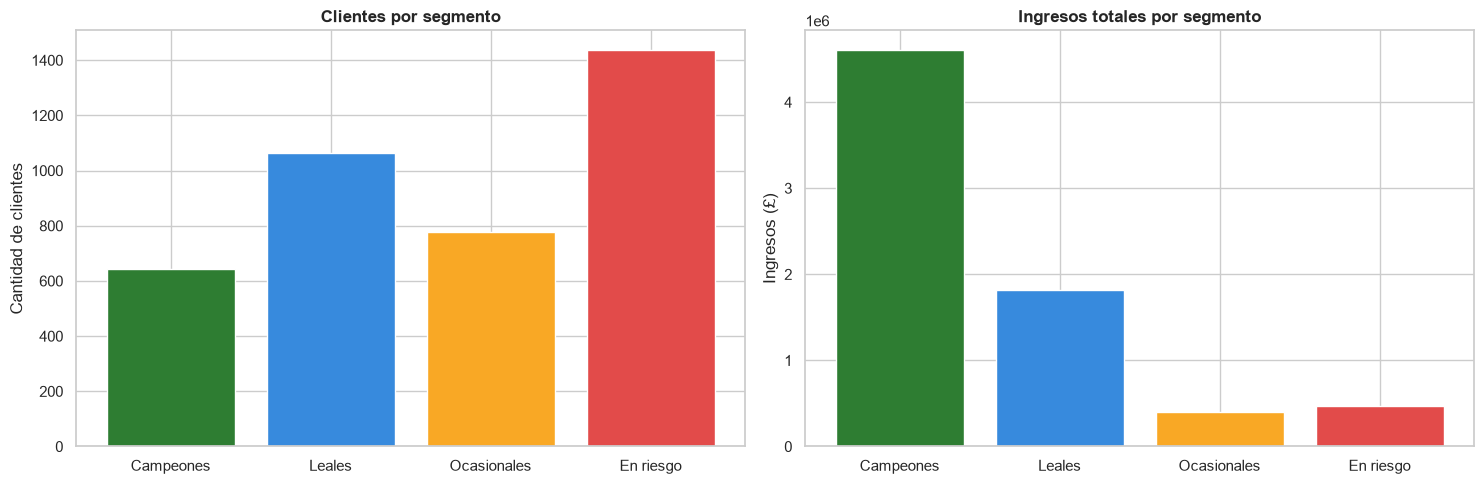

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden = ["Campeones", "Leales", "Ocasionales", "En riesgo"]
colores = {"Campeones": "#2E7D32", "Leales": "#378ADD", "Ocasionales": "#F9A825", "En riesgo": "#E24B4A"}

conteo = rfm["Segmento"].value_counts().reindex(orden)
axes[0].bar(conteo.index, conteo.values, color=[colores[s] for s in conteo.index])
axes[0].set_title("Clientes por segmento", fontweight="bold")
axes[0].set_ylabel("Cantidad de clientes")

ingreso_seg = rfm.groupby("Segmento")["Monetario"].sum().reindex(orden)
axes[1].bar(ingreso_seg.index, ingreso_seg.values, color=[colores[s] for s in ingreso_seg.index])
axes[1].set_title("Ingresos totales por segmento", fontweight="bold")
axes[1].set_ylabel("Ingresos (£)")

plt.tight_layout()
plt.show()


El contraste entre los dos gráficos es revelador. Los Campeones son una fracción de los clientes pero aportan una porción enorme de los ingresos, mientras que los clientes En riesgo son numerosos pero pesan poco. La estrategia se ordena sola, proteger a los campeones, hacer crecer a los leales y ocasionales, y reactivar a los que están en riesgo solo si el costo lo justifica.


### Visualización de las agrupaciones

Las barras anteriores muestran el tamaño y el aporte de cada segmento, pero no cómo se separan los clientes. Para verlo se proyectan las tres variables RFM en dos dimensiones con un análisis de componentes principales, que conserva la mayor parte de la información, y se grafican también los pares de variables originales. Cada punto es un cliente, coloreado según su segmento.


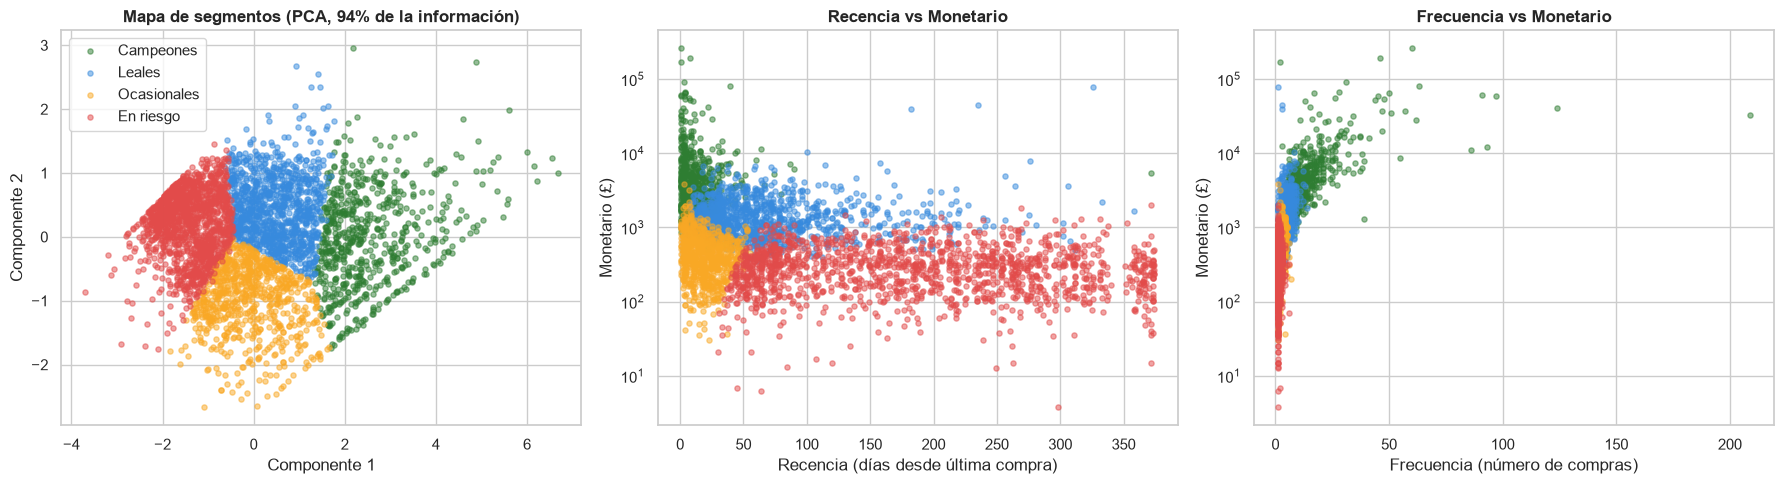

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_esc)
rfm["pca1"], rfm["pca2"] = coords[:, 0], coords[:, 1]
var_exp = pca.explained_variance_ratio_.sum() * 100

orden = ["Campeones", "Leales", "Ocasionales", "En riesgo"]
colores = {"Campeones": "#2E7D32", "Leales": "#378ADD", "Ocasionales": "#F9A825", "En riesgo": "#E24B4A"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for seg in orden:
    sub = rfm[rfm["Segmento"] == seg]
    axes[0].scatter(sub["pca1"], sub["pca2"], s=14, alpha=0.5, color=colores[seg], label=seg)
axes[0].set_title(f"Mapa de segmentos (PCA, {var_exp:.0f}% de la información)", fontweight="bold")
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")
axes[0].legend()

for seg in orden:
    sub = rfm[rfm["Segmento"] == seg]
    axes[1].scatter(sub["Recencia"], sub["Monetario"], s=14, alpha=0.5, color=colores[seg])
axes[1].set_title("Recencia vs Monetario", fontweight="bold")
axes[1].set_xlabel("Recencia (días desde última compra)")
axes[1].set_ylabel("Monetario (£)")
axes[1].set_yscale("log")

for seg in orden:
    sub = rfm[rfm["Segmento"] == seg]
    axes[2].scatter(sub["Frecuencia"], sub["Monetario"], s=14, alpha=0.5, color=colores[seg])
axes[2].set_title("Frecuencia vs Monetario", fontweight="bold")
axes[2].set_xlabel("Frecuencia (número de compras)")
axes[2].set_ylabel("Monetario (£)")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()


Los grupos se separan con claridad. El mapa de componentes principales muestra cuatro nubes diferenciadas, y los gráficos de las variables originales lo confirman. Los Campeones se ubican donde la recencia es baja y la frecuencia y el gasto son altos, abajo a la izquierda en recencia y arriba en monto. Los clientes En riesgo ocupan el extremo opuesto, recencia alta y poca actividad. Entre medio quedan los Leales y Ocasionales. Esta vista hace tangible la segmentación, no son etiquetas arbitrarias sino regiones reales del comportamiento de compra.


### ¿Los segmentos son estadísticamente distintos?

Para confirmar que los grupos no son un artificio del algoritmo se comprueba con una prueba de hipótesis que el gasto difiere de verdad entre segmentos. Se usa ANOVA y su versión no paramétrica de Kruskal-Wallis, apropiada porque el gasto no es normal.


In [18]:
grupos_seg = [rfm[rfm["Segmento"] == s]["Monetario"] for s in orden]

f_stat, p_anova = stats.f_oneway(*grupos_seg)
h_stat, p_kruskal = stats.kruskal(*grupos_seg)

print(f"ANOVA del gasto entre segmentos:  F = {f_stat:.1f}   p = {p_anova:.1e}")
print(f"Kruskal-Wallis (no paramétrica):  p = {p_kruskal:.1e}")
print("\nConclusión:", "los segmentos difieren significativamente en gasto" if p_anova < 0.05 else "sin diferencia")


ANOVA del gasto entre segmentos:  F = 152.0   p = 3.4e-93
Kruskal-Wallis (no paramétrica):  p = 0.0e+00

Conclusión: los segmentos difieren significativamente en gasto


Ambas pruebas dan un p-valor prácticamente cero, así que las diferencias de gasto entre segmentos son reales y no producto del azar. Esto valida estadísticamente la segmentación, los grupos que encontró K-Means corresponden a comportamientos de compra genuinamente distintos.


## 5. Reglas de asociación para recomendaciones

La segunda parte de la pregunta es qué productos conviene recomendar o promocionar juntos. Para responderlo se usa el análisis de canasta, que busca productos que tienden a comprarse en la misma factura.

Se arma una matriz donde cada fila es una factura y cada columna un producto, marcando si estuvo o no. Sobre ella se aplica el algoritmo FP-Growth para encontrar combinaciones frecuentes, y luego se derivan reglas del tipo quien compra A también compra B.


In [19]:
cesta = (
    df.groupby(["InvoiceNo", "Description"])["Quantity"].sum().unstack().fillna(0)
)
cesta = cesta > 0
print(f"Matriz de canasta: {cesta.shape[0]:,} facturas x {cesta.shape[1]:,} productos")

frecuentes = fpgrowth(cesta, min_support=0.02, use_colnames=True)
reglas = association_rules(frecuentes, metric="lift", min_threshold=1)
print(f"Conjuntos frecuentes encontrados: {len(frecuentes)}")
print(f"Reglas con lift mayor a 1: {len(reglas)}")


Matriz de canasta: 18,019 facturas x 4,007 productos


Conjuntos frecuentes encontrados: 400
Reglas con lift mayor a 1: 218


Las tres métricas que importan son el soporte, que indica qué tan común es la combinación, la confianza, que es la probabilidad de comprar B habiendo comprado A, y el lift, que mide cuánto más probable es esa compra conjunta frente al azar. Un lift de 10 significa que comprar ambos juntos es diez veces más frecuente de lo esperable si fueran independientes.


In [20]:
top_reglas = reglas.sort_values("lift", ascending=False).head(10).copy()
top_reglas["antecedente"] = top_reglas["antecedents"].apply(lambda s: ", ".join(list(s)))
top_reglas["consecuente"] = top_reglas["consequents"].apply(lambda s: ", ".join(list(s)))
top_reglas[["antecedente", "consecuente", "support", "confidence", "lift"]].round(3).reset_index(drop=True)


,antecedente,consecuente,support,confidence,lift
0,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.020,0.768,27.197
1,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.020,0.723,27.197
2,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.027,0.701,18.041
3,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.027,0.703,18.041
4,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.027,0.528,17.454
5,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.027,0.903,17.454
6,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.027,0.854,16.100
7,ROSES REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY ...",0.027,0.515,16.100
8,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.032,0.821,15.864
9,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.032,0.618,15.864


Las reglas más fuertes tienen un sentido comercial inmediato. Los juegos de tazas y platos de la misma colección aparecen juntos una y otra vez, con lifts superiores a 20. Lo mismo ocurre con conjuntos de productos temáticos que forman una colección. Quien compra una pieza tiende a llevar las demás del juego.

Esto se traduce en acciones concretas. Estos productos se pueden ofrecer empaquetados, recomendar de forma cruzada en la ficha del producto, o ubicar juntos para impulsar la venta del conjunto completo.


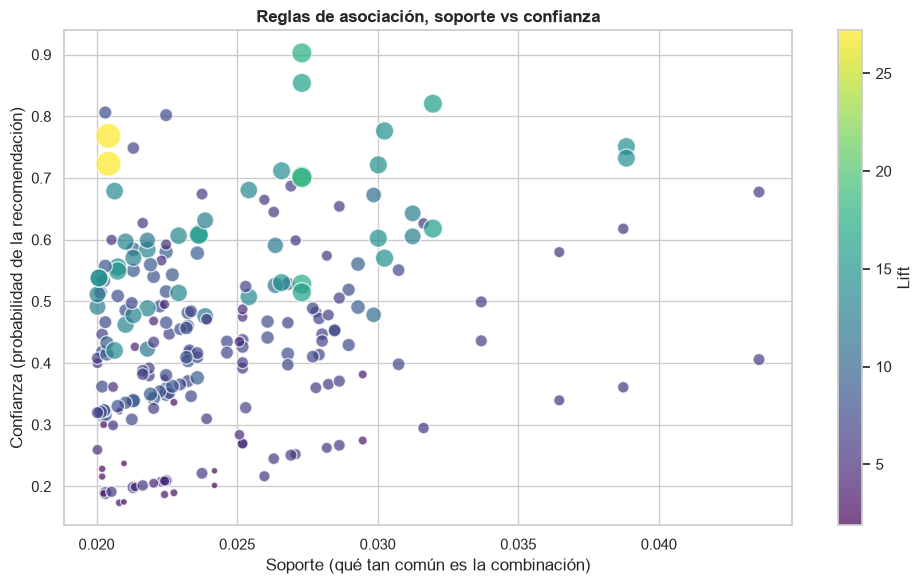

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(reglas["support"], reglas["confidence"],
                s=reglas["lift"] * 12, c=reglas["lift"], cmap="viridis", alpha=0.7, edgecolor="white")
ax.set_title("Reglas de asociación, soporte vs confianza", fontweight="bold")
ax.set_xlabel("Soporte (qué tan común es la combinación)")
ax.set_ylabel("Confianza (probabilidad de la recomendación)")
plt.colorbar(sc, label="Lift")
plt.tight_layout()
plt.show()


Cada burbuja es una regla. Las más valiosas para recomendar son las que combinan confianza alta, que asegura que la sugerencia acierte seguido, con un lift alto, que garantiza que la relación es real y no casualidad. Las del extremo superior con burbujas grandes son las candidatas ideales para una estrategia de venta cruzada.


## 6. Tablero resumen

El tablero reúne en una vista los hallazgos principales que responden a la pregunta inicial. Combina los indicadores del negocio, la segmentación de clientes y las oportunidades de venta cruzada.


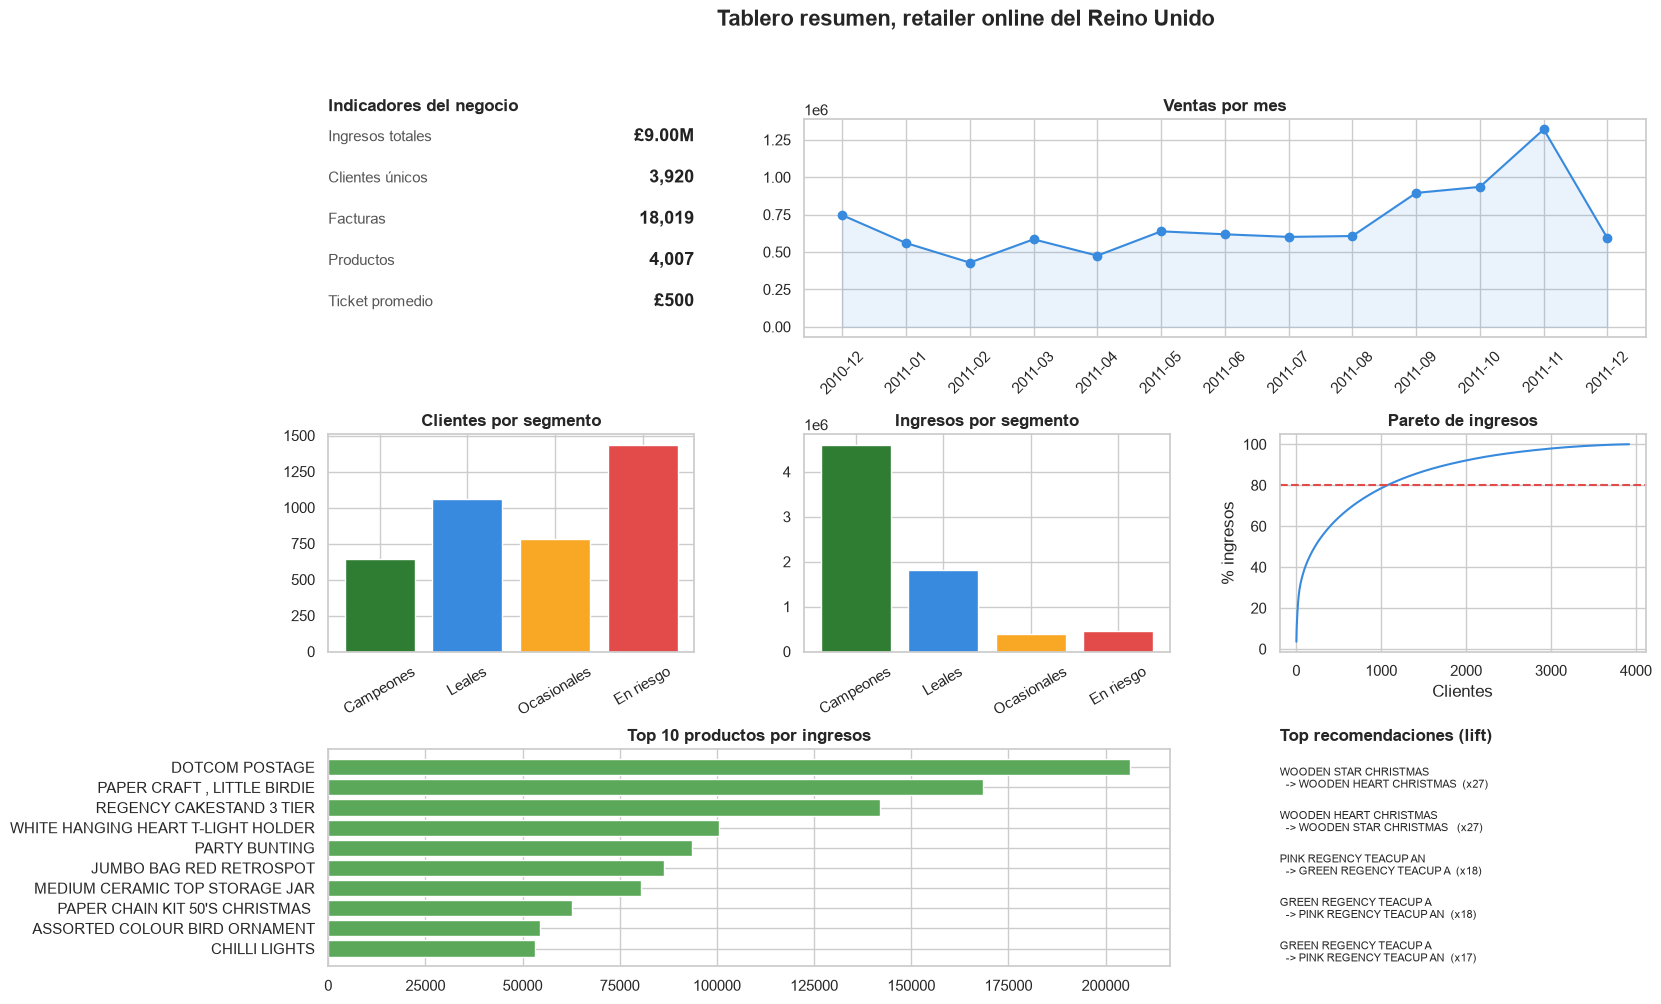

In [22]:
fig = plt.figure(figsize=(17, 11))
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.3)

# KPIs
ax0 = fig.add_subplot(gs[0, 0])
ax0.axis("off")
kpis = [
    ("Ingresos totales", f"£{df['TotalPrice'].sum()/1e6:.2f}M"),
    ("Clientes únicos", f"{df_cli['CustomerID'].nunique():,}"),
    ("Facturas", f"{df['InvoiceNo'].nunique():,}"),
    ("Productos", f"{df['Description'].nunique():,}"),
    ("Ticket promedio", f"£{df.groupby('InvoiceNo')['TotalPrice'].sum().mean():.0f}"),
]
y = 0.9
for nombre, val in kpis:
    ax0.text(0.0, y, nombre, fontsize=11, color="#555")
    ax0.text(1.0, y, val, fontsize=13, fontweight="bold", ha="right", color="#222")
    y -= 0.19
ax0.set_title("Indicadores del negocio", fontweight="bold", loc="left")

# Ventas por mes
ax1 = fig.add_subplot(gs[0, 1:])
ax1.plot(ventas_mes.index, ventas_mes.values, marker="o", color="#378ADD")
ax1.fill_between(range(len(ventas_mes)), ventas_mes.values, alpha=0.1, color="#378ADD")
ax1.set_title("Ventas por mes", fontweight="bold")
ax1.tick_params(axis="x", rotation=45)

# Clientes por segmento
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(conteo.index, conteo.values, color=[colores[s] for s in conteo.index])
ax2.set_title("Clientes por segmento", fontweight="bold")
ax2.tick_params(axis="x", rotation=30)

# Ingresos por segmento
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(ingreso_seg.index, ingreso_seg.values, color=[colores[s] for s in ingreso_seg.index])
ax3.set_title("Ingresos por segmento", fontweight="bold")
ax3.tick_params(axis="x", rotation=30)

# Pareto
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(range(1, len(acumulado) + 1), acumulado.values * 100, color="#378ADD")
ax4.axhline(80, color="#E24B4A", linestyle="--")
ax4.set_title("Pareto de ingresos", fontweight="bold")
ax4.set_xlabel("Clientes")
ax4.set_ylabel("% ingresos")

# Top productos
ax5 = fig.add_subplot(gs[2, :2])
ax5.barh(top_prod.index[::-1], top_prod.values[::-1], color="#5BA85B")
ax5.set_title("Top 10 productos por ingresos", fontweight="bold")

# Top reglas
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")
ax6.set_title("Top recomendaciones (lift)", fontweight="bold", loc="left")
y = 0.92
for _, r in reglas.sort_values("lift", ascending=False).head(5).iterrows():
    a = list(r["antecedents"])[0][:22]
    c = list(r["consequents"])[0][:22]
    ax6.text(0.0, y, f"{a}\n  -> {c}  (x{r['lift']:.0f})", fontsize=8, va="top")
    y -= 0.2

fig.suptitle("Tablero resumen, retailer online del Reino Unido", fontsize=16, fontweight="bold", y=0.98)
plt.show()


## 7. Conclusiones

El análisis responde la pregunta inicial sobre quiénes son los mejores clientes y qué productos conviene recomendar.

Sobre los clientes, el negocio depende de una minoría. Cerca del 27% genera el 80% de los ingresos, y la segmentación los identifica con nombre propio. Los Campeones, pocos pero de altísimo valor, son la prioridad de retención. Los Leales y Ocasionales son la cantera de crecimiento. Los clientes En riesgo, numerosos pero de bajo aporte, justifican campañas de reactivación solo cuando el costo lo permita.

Sobre los productos, las reglas de asociación revelan colecciones que se compran juntas de forma muy consistente, con tazas, platos y artículos temáticos de la misma línea apareciendo en las mismas facturas mucho más de lo esperable por azar. Esas combinaciones son oportunidades directas de venta cruzada, empaquetado y recomendación.

Sobre el método, cada etapa alimentó a la siguiente. La limpieza preparó datos confiables, el análisis estadístico reveló la fuerte estacionalidad y la concentración de ingresos que motivaron la segmentación, y la segmentación junto con las reglas de asociación tradujeron los datos en acciones concretas de marketing. El tablero final reúne todo en una vista lista para decidir.
